# Сравнение сверточных моделей для последовательностей

В этом ноутбуке сравниваются несколько 1D-CNN архитектур для клиентских последовательностей транзакций.
Пайплайн данных совпадает с recurrent и transformers: используются `*_clean.csv`, транзакции внутри клиента сортируются по времени, затем формируются последовательности длиной до 100 операций.

## Часть 1: Настройка окружения

In [1]:
import logging
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seeds(42)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
logger.info(f"Окружение инициализировано. Устройство: {device}")

2026-05-12 11:20:26,239 - INFO - Окружение инициализировано. Устройство: mps


## Часть 2: Загрузка и подготовка данных

In [2]:
DATA_DIR = Path("../data")

df_train = pd.read_csv(DATA_DIR / "train_clean.csv", index_col=False)
df_val = pd.read_csv(DATA_DIR / "val_clean.csv", index_col=False)
df_test = pd.read_csv(DATA_DIR / "test_clean.csv", index_col=False)

logger.info(f"Тренировочный набор: {df_train.shape[0]:,} транзакций x {df_train.shape[1]} колонок")
logger.info(f"Валидационный набор: {df_val.shape[0]:,} транзакций x {df_val.shape[1]} колонок")
logger.info(f"Тестовый набор: {df_test.shape[0]:,} транзакций x {df_test.shape[1]} колонок")
logger.info(f"Доля мошенничества (тренировка): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (валидация): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (тест): {df_test['FraudResult'].mean():.2%}")

print("\nСводка данных:")
print(f"  Источник: {DATA_DIR}")
print(f"  Уникальных клиентов (тренировка): {df_train['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (валидация): {df_val['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (тест): {df_test['CustomerId'].nunique():,}")
print(f"  Средний размер последовательности: {len(df_train) / df_train['CustomerId'].nunique():.1f} транзакций")

2026-05-12 11:20:26,357 - INFO - Тренировочный набор: 57,364 транзакций x 24 колонок
2026-05-12 11:20:26,358 - INFO - Валидационный набор: 19,162 транзакций x 24 колонок
2026-05-12 11:20:26,358 - INFO - Тестовый набор: 19,136 транзакций x 24 колонок
2026-05-12 11:20:26,360 - INFO - Доля мошенничества (тренировка): 0.20%
2026-05-12 11:20:26,360 - INFO - Доля мошенничества (валидация): 0.21%
2026-05-12 11:20:26,360 - INFO - Доля мошенничества (тест): 0.20%



Сводка данных:
  Источник: ../data
  Уникальных клиентов (тренировка): 2,245
  Уникальных клиентов (валидация): 748
  Уникальных клиентов (тест): 749
  Средний размер последовательности: 25.6 транзакций


## Часть 3: Использование подготовленных признаков и создание последовательностей

In [3]:
FEATURE_COLS = [
    "Amount",
    "abs_amount",
    "log_abs_amount",
    "amount_sign",
    "is_negative_amount",
    "tx_month",
    "tx_day",
    "tx_hour",
    "tx_minute",
    "tx_dayofweek",
    "tx_is_weekend",
    "tx_elapsed_seconds",
    "tx_elapsed_days",
    "tx_hour_sin",
    "tx_hour_cos",
    "tx_dayofweek_sin",
    "tx_dayofweek_cos",
    "ProviderId_id",
    "ProductId_id",
    "ProductCategory_id",
    "ChannelId_id",
    "PricingStrategy_id",
]

TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"
SORT_COLS = ["tx_elapsed_seconds", "tx_elapsed_days", "tx_month", "tx_day", "tx_hour", "tx_minute"]

train_features = df_train[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
val_features = df_val[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
test_features = df_test[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()

logger.info("Используются признаки, подготовленные в data/cleanup.ipynb")
logger.info(f"Признаков в последовательности: {len(FEATURE_COLS)}")
logger.info(f"Колонки сортировки транзакций: {SORT_COLS}")

2026-05-12 11:20:26,381 - INFO - Используются признаки, подготовленные в data/cleanup.ipynb
2026-05-12 11:20:26,381 - INFO - Признаков в последовательности: 22
2026-05-12 11:20:26,381 - INFO - Колонки сортировки транзакций: ['tx_elapsed_seconds', 'tx_elapsed_days', 'tx_month', 'tx_day', 'tx_hour', 'tx_minute']


### Создание последовательностей для каждого клиента

In [4]:
def create_client_sequences(df, max_seq_len=100, feature_cols=None):
    """
    Организация транзакций в последовательности по клиентам.
    Транзакции внутри каждого клиента сортируются по времени перед обрезкой.
    """
    if feature_cols is None:
        feature_cols = FEATURE_COLS

    sequences = []
    labels = []
    client_ids = []
    available_sort_cols = [col for col in SORT_COLS if col in df.columns]

    for account_id, group in df.groupby(CLIENT_ID_COL, sort=False):
        if available_sort_cols:
            group = group.sort_values(available_sort_cols, kind="mergesort")

        seq = group[feature_cols].values.astype(np.float32)

        if len(seq) > max_seq_len:
            seq = seq[-max_seq_len:]

        if len(seq) < max_seq_len:
            padding = np.zeros((max_seq_len - len(seq), seq.shape[1]), dtype=np.float32)
            seq = np.vstack([padding, seq])

        label = int(group[TARGET_COL].max())

        sequences.append(seq)
        labels.append(label)
        client_ids.append(account_id)

    return np.array(sequences), np.array(labels), np.array(client_ids), list(feature_cols)


logger.info("Создание последовательностей клиентов...")
train_sequences, train_labels, train_clients, feature_cols = create_client_sequences(
    train_features,
    feature_cols=FEATURE_COLS,
)
val_sequences, val_labels, val_clients, _ = create_client_sequences(
    val_features,
    feature_cols=feature_cols,
)
test_sequences, test_labels, test_clients, _ = create_client_sequences(
    test_features,
    feature_cols=feature_cols,
)

logger.info(f"Тренировочные последовательности: {train_sequences.shape}")
logger.info(f"Валидационные последовательности: {val_sequences.shape}")
logger.info(f"Тестовые последовательности: {test_sequences.shape}")
logger.info(f"Распределение меток (тренировка): {np.bincount(train_labels)}")
logger.info(f"Распределение меток (валидация): {np.bincount(val_labels)}")
logger.info(f"Распределение меток (тест): {np.bincount(test_labels)}")
logger.info(f"Всего признаков в последовательности: {len(feature_cols)}")

print(f"\nРазмер последовательностей:")
print(f"  Максимальная длина: 100 транзакций")
print(f"  Размер признаков: {train_sequences.shape[2]}")
print(f"  Клиентов (тренировка): {len(train_sequences)}")
print(f"  Клиентов (валидация): {len(val_sequences)}")
print(f"  Клиентов (тест): {len(test_sequences)}")

2026-05-12 11:20:26,388 - INFO - Создание последовательностей клиентов...
2026-05-12 11:20:28,011 - INFO - Тренировочные последовательности: (2245, 100, 22)
2026-05-12 11:20:28,011 - INFO - Валидационные последовательности: (748, 100, 22)
2026-05-12 11:20:28,012 - INFO - Тестовые последовательности: (749, 100, 22)
2026-05-12 11:20:28,012 - INFO - Распределение меток (тренировка): [2213   32]
2026-05-12 11:20:28,012 - INFO - Распределение меток (валидация): [737  11]
2026-05-12 11:20:28,012 - INFO - Распределение меток (тест): [738  11]
2026-05-12 11:20:28,013 - INFO - Всего признаков в последовательности: 22



Размер последовательностей:
  Максимальная длина: 100 транзакций
  Размер признаков: 22
  Клиентов (тренировка): 2245
  Клиентов (валидация): 748
  Клиентов (тест): 749


### Нормализация признаков

In [5]:
n_clients, seq_len, n_features = train_sequences.shape
training_reshaped = train_sequences.reshape(-1, n_features)

scaler = StandardScaler()
training_scaled_reshaped = scaler.fit_transform(training_reshaped)
training_sequences_scaled = training_scaled_reshaped.reshape(n_clients, seq_len, n_features)

val_reshaped = val_sequences.reshape(-1, n_features)
val_scaled_reshaped = scaler.transform(val_reshaped)
val_sequences_scaled = val_scaled_reshaped.reshape(val_sequences.shape[0], seq_len, n_features)

test_reshaped = test_sequences.reshape(-1, n_features)
test_scaled_reshaped = scaler.transform(test_reshaped)
test_sequences_scaled = test_scaled_reshaped.reshape(test_sequences.shape[0], seq_len, n_features)

logger.info("Признаки нормализованы")
print(f"Нормализация - статистика тренировки:")
print(f"  Mean: {training_sequences_scaled.reshape(-1, n_features).mean(axis=0)[:5]}...")
print(f"  Std:  {training_sequences_scaled.reshape(-1, n_features).std(axis=0)[:5]}...")

2026-05-12 11:20:28,051 - INFO - Признаки нормализованы


Нормализация - статистика тренировки:
  Mean: [-4.3345003e-06 -2.5165941e-06 -9.7838507e-05 -5.6253055e-05
  1.5194544e-04]...
  Std:  [0.9996615 0.9996004 1.0007588 1.0006154 0.9976402]...


### Преобразование в PyTorch tensors

In [6]:
X_train_tensor = torch.FloatTensor(training_sequences_scaled)
y_train_tensor = torch.LongTensor(train_labels)

X_val_tensor = torch.FloatTensor(val_sequences_scaled)
y_val_tensor = torch.LongTensor(val_labels)

X_test_tensor = torch.FloatTensor(test_sequences_scaled)
y_test_tensor = torch.LongTensor(test_labels)

logger.info(f"Тренировочные тензоры: {X_train_tensor.shape}")
logger.info(f"Валидационные тензоры: {X_val_tensor.shape}")
logger.info(f"Тестовые тензоры: {X_test_tensor.shape}")

2026-05-12 11:20:28,073 - INFO - Тренировочные тензоры: torch.Size([2245, 100, 22])
2026-05-12 11:20:28,074 - INFO - Валидационные тензоры: torch.Size([748, 100, 22])
2026-05-12 11:20:28,074 - INFO - Тестовые тензоры: torch.Size([749, 100, 22])


## Часть 4: Архитектуры сверточных моделей для последовательностей

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout=0.2, dilation=1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.block(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.2, dilation=1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = F.gelu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        return F.gelu(x + residual)


class ConvMeanClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = x.mean(dim=2)
        return self.classifier(pooled)


class ConvMaxClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = x.max(dim=2).values
        return self.classifier(pooled)


class ConvMeanMaxClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        mean_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=1))


class ResidualCNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=4, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        self.input_proj = ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)
        self.blocks = nn.Sequential(*[
            ResidualConvBlock(hidden_dim, kernel_size=kernel_size, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        x = self.blocks(x)
        pooled = torch.cat([x.mean(dim=2), x.max(dim=2).values], dim=1)
        return self.classifier(pooled)


class DilatedCNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=1),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=2),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=4),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=8),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = torch.cat([x.mean(dim=2), x.max(dim=2).values], dim=1)
        return self.classifier(pooled)


class CNNAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.attention = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(hidden_dim, 1, kernel_size=1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        attn_weights = torch.softmax(self.attention(x), dim=2)
        attn_pool = (x * attn_weights).sum(dim=2)
        mean_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        return self.classifier(torch.cat([attn_pool, mean_pool, max_pool], dim=1))

In [8]:
model_configs = {
    "ConvMean": {
        "model_type": "conv_mean",
        "hidden_dim": 64,
        "num_layers": 3,
        "kernel_size": 3,
        "dropout": 0.2,
    },
    "ConvMax": {
        "model_type": "conv_max",
        "hidden_dim": 64,
        "num_layers": 3,
        "kernel_size": 3,
        "dropout": 0.2,
    },
    "ConvMeanMax": {
        "model_type": "conv_meanmax",
        "hidden_dim": 64,
        "num_layers": 3,
        "kernel_size": 3,
        "dropout": 0.2,
    },
    "ResidualCNN": {
        "model_type": "residual_cnn",
        "hidden_dim": 64,
        "num_layers": 4,
        "kernel_size": 3,
        "dropout": 0.2,
    },
    "DilatedCNN": {
        "model_type": "dilated_cnn",
        "hidden_dim": 64,
        "kernel_size": 3,
        "dropout": 0.2,
    },
    "CNNAttention": {
        "model_type": "cnn_attention",
        "hidden_dim": 64,
        "num_layers": 3,
        "kernel_size": 3,
        "dropout": 0.2,
    },
}


def build_model(config, input_dim, num_classes=2):
    model_type = config["model_type"]
    common_kwargs = {
        "input_dim": input_dim,
        "hidden_dim": config["hidden_dim"],
        "kernel_size": config.get("kernel_size", 3),
        "dropout": config.get("dropout", 0.2),
        "num_classes": num_classes,
    }

    if model_type == "conv_mean":
        return ConvMeanClassifier(num_layers=config["num_layers"], **common_kwargs)
    if model_type == "conv_max":
        return ConvMaxClassifier(num_layers=config["num_layers"], **common_kwargs)
    if model_type == "conv_meanmax":
        return ConvMeanMaxClassifier(num_layers=config["num_layers"], **common_kwargs)
    if model_type == "residual_cnn":
        return ResidualCNNClassifier(num_layers=config["num_layers"], **common_kwargs)
    if model_type == "dilated_cnn":
        return DilatedCNNClassifier(**common_kwargs)
    if model_type == "cnn_attention":
        return CNNAttentionClassifier(num_layers=config["num_layers"], **common_kwargs)

    raise ValueError(f"Неизвестный тип модели: {model_type}")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for model_name, config in model_configs.items():
    model = build_model(config, input_dim=n_features)
    logger.info(f"{model_name}: {count_parameters(model):,} параметров")

2026-05-12 11:20:28,106 - INFO - ConvMean: 33,666 параметров
2026-05-12 11:20:28,107 - INFO - ConvMax: 33,666 параметров
2026-05-12 11:20:28,108 - INFO - ConvMeanMax: 37,762 параметров
2026-05-12 11:20:28,109 - INFO - ResidualCNN: 112,642 параметров
2026-05-12 11:20:28,110 - INFO - DilatedCNN: 50,242 параметров
2026-05-12 11:20:28,111 - INFO - CNNAttention: 46,083 параметров


## Часть 5: Обучение и сравнение моделей

In [9]:
def train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def predict_on_loader(model, data_loader, device):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            scores.extend(probs)
            labels.extend(y_batch.numpy())

    return np.array(labels), np.array(scores)


def find_best_threshold(y_true, y_score, beta=0.5):
    thresholds = np.arange(0.0, 1.01, 0.01)
    fbeta_scores = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        fbeta_scores.append(fbeta_score(y_true, y_pred, beta=beta, zero_division=0))

    best_idx = int(np.argmax(fbeta_scores))
    return thresholds[best_idx], fbeta_scores[best_idx], thresholds, fbeta_scores


def calculate_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F0.5": fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

## Часть 6: Сравнительная оценка моделей

In [10]:
results = []
histories = {}

batch_size = 64
num_epochs = 40
patience = 10
learning_rate = 1e-3
weight_decay = 1e-4
clip_grad = 1.0

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False,
)

class_counts = np.bincount(train_labels)
class_weights = torch.tensor(
    [1.0, class_counts[0] / max(class_counts[1], 1)],
    dtype=torch.float32,
    device=device,
)

for model_name, config in model_configs.items():
    reset_seeds(42)

    logger.info("=" * 90)
    logger.info(f"Запуск модели: {model_name}")
    logger.info(f"Конфиг: {config}")
    logger.info("=" * 90)

    model = build_model(config, input_dim=n_features).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    train_losses = []
    val_pr_auc_scores = []
    best_val_pr_auc = 0.0
    best_epoch = 0
    best_state_dict = None
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=clip_grad)
        y_val_true, y_val_score = predict_on_loader(model, val_loader, device)
        val_pr_auc = average_precision_score(y_val_true, y_val_score)

        scheduler.step()

        train_losses.append(train_loss)
        val_pr_auc_scores.append(val_pr_auc)

        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            best_epoch = epoch + 1
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            logger.info(
                f"{model_name} | эпоха {epoch + 1:02d} | "
                f"train_loss={train_loss:.4f} | val_pr_auc={val_pr_auc:.4f}"
            )

        if patience_counter >= patience:
            logger.info(f"{model_name}: ранняя остановка на эпохе {epoch + 1}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    y_val_true, y_val_score = predict_on_loader(model, val_loader, device)
    best_threshold, best_f05, thresholds, f05_scores = find_best_threshold(y_val_true, y_val_score)

    y_test_true, y_test_score = predict_on_loader(model, test_loader, device)
    metrics = calculate_metrics(y_test_true, y_test_score, threshold=best_threshold)

    result = {
        "Model": model_name,
        "Params": count_parameters(model),
        "Best Val PR-AUC": best_val_pr_auc,
        "Best Epoch": best_epoch,
        "Best Threshold": best_threshold,
        "Best Val F0.5": best_f05,
        **metrics,
    }
    results.append(result)

    histories[model_name] = {
        "train_losses": train_losses,
        "val_pr_auc_scores": val_pr_auc_scores,
        "thresholds": thresholds,
        "f05_scores": f05_scores,
    }

    logger.info(
        f"{model_name}: test PR-AUC={metrics['PR-AUC']:.4f}, "
        f"ROC-AUC={metrics['ROC-AUC']:.4f}, "
        f"F0.5={metrics['F0.5']:.4f}, "
        f"Precision={metrics['Precision']:.4f}, "
        f"Recall={metrics['Recall']:.4f}"
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["F0.5", "PR-AUC"], ascending=False).reset_index(drop=True)

print("\nСводная таблица результатов:")
display(results_df)

2026-05-12 11:20:28,323 - INFO - ==========================================================================================
2026-05-12 11:20:28,323 - INFO - Запуск модели: ConvMean
2026-05-12 11:20:28,324 - INFO - Конфиг: {'model_type': 'conv_mean', 'hidden_dim': 64, 'num_layers': 3, 'kernel_size': 3, 'dropout': 0.2}
2026-05-12 11:20:28,324 - INFO - ==========================================================================================
2026-05-12 11:20:34,720 - INFO - ConvMean | эпоха 05 | train_loss=0.2727 | val_pr_auc=0.7989
2026-05-12 11:20:35,980 - INFO - ConvMean | эпоха 10 | train_loss=0.0948 | val_pr_auc=0.7604
2026-05-12 11:20:37,562 - INFO - ConvMean | эпоха 15 | train_loss=0.0588 | val_pr_auc=0.7461
2026-05-12 11:20:37,887 - INFO - ConvMean: ранняя остановка на эпохе 16
2026-05-12 11:20:38,028 - INFO - ConvMean: test PR-AUC=0.7645, ROC-AUC=0.9947, F0.5=0.6383, Precision=0.6667, Recall=0.5455
2026-05-12 11:20:38,031 - INFO - =================================================


Сводная таблица результатов:


,Model,Params,Best Val PR-AUC,Best Epoch,Best Threshold,Best Val F0.5,ROC-AUC,PR-AUC,Accuracy,Precision,...,F1,F0.5,Specificity,FPR,FNR,NPV,TN,FP,FN,TP
0,DilatedCNN,50242,0.858319,2,0.80,0.774648,0.994703,0.804506,0.993324,0.750000,...,0.782609,0.762712,0.995935,0.004065,0.181818,0.997286,735,3,2,9
1,ResidualCNN,112642,0.840325,1,0.45,0.818182,0.993102,0.786400,0.991989,0.727273,...,0.727273,0.727273,0.995935,0.004065,0.272727,0.995935,735,3,3,8
2,ConvMax,33666,0.850876,2,0.50,0.818182,0.995935,0.803085,0.991989,0.692308,...,0.750000,0.714286,0.994580,0.005420,0.181818,0.997283,734,4,2,9
3,CNNAttention,46083,0.836113,1,0.62,0.818182,0.992486,0.801159,0.991989,0.692308,...,0.750000,0.714286,0.994580,0.005420,0.181818,0.997283,734,4,2,9
4,ConvMeanMax,37762,0.853773,3,0.84,0.784314,0.992609,0.776279,0.991989,0.692308,...,0.750000,0.714286,0.994580,0.005420,0.181818,0.997283,734,4,2,9
5,ConvMean,33666,0.809149,6,0.64,0.744681,0.994703,0.764512,0.989319,0.666667,...,0.600000,0.638298,0.995935,0.004065,0.454545,0.993243,735,3,5,6


## Часть 7: Визуализация результатов сравнения

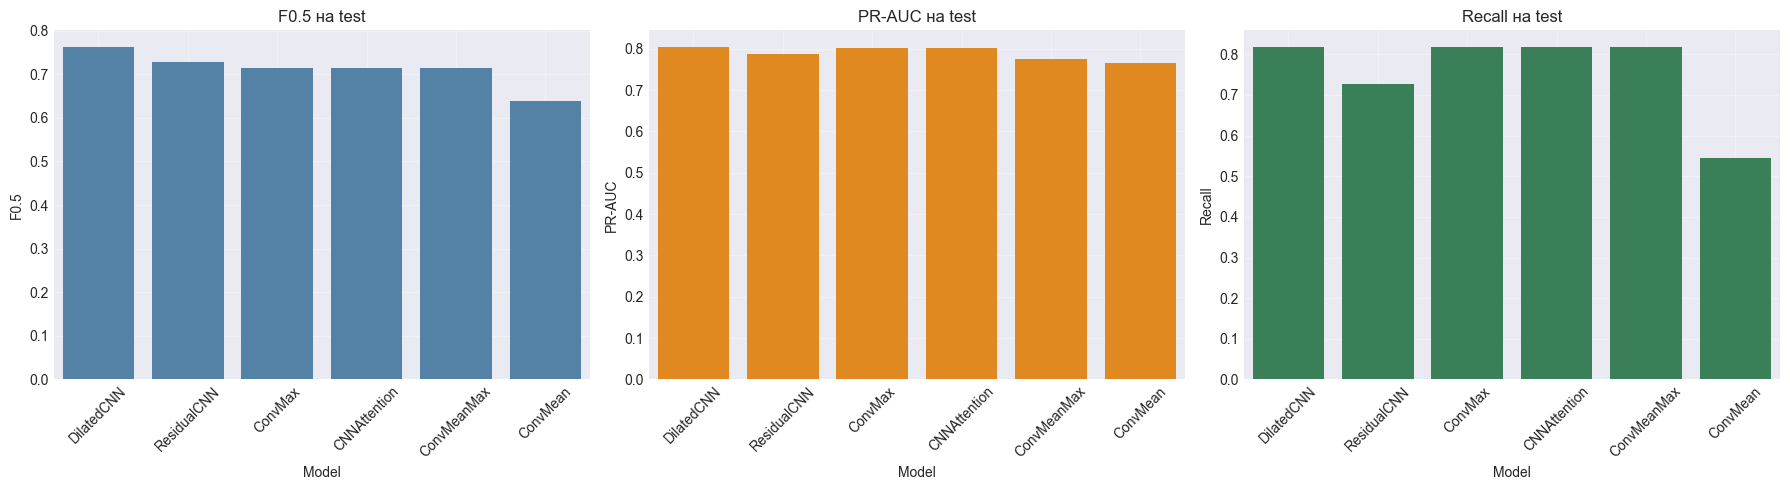

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="Model", y="F0.5", ax=axes[0], color="steelblue")
axes[0].set_title("F0.5 на test")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)

sns.barplot(data=results_df, x="Model", y="PR-AUC", ax=axes[1], color="darkorange")
axes[1].set_title("PR-AUC на test")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

sns.barplot(data=results_df, x="Model", y="Recall", ax=axes[2], color="seagreen")
axes[2].set_title("Recall на test")
axes[2].tick_params(axis="x", rotation=45)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()